# Sistema Inteligente de Análise Financeira e Consumo: Insights para o Futuro

Este projeto visa transformar dados brutos de consumo em inteligência financeira acionável. Através de uma abordagem completa que abrange desde a extração e limpeza de dados até a aplicação de técnicas avançadas de Machine Learning e visualizações intuitivas, nosso objetivo é capacitar os usuários a compreenderem seus hábitos de gastos, identificarem padrões e, finalmente, preverem seus compromissos financeiros. Descubra como desvendamos os segredos por trás de cada transação para oferecer um controle financeiro sem precedentes e insights que impulsionam decisões mais inteligentes.

---

### Visão Geral do Projeto

Neste projeto, embarcamos na missão de construir um sistema inteligente capaz de analisar perfis financeiros, padrões de consumo e gerar insights acionáveis. Nosso objetivo principal é capacitar usuários finais a tomar decisões financeiras mais informadas, identificar gastos supérfluos e prever com maior precisão o fechamento de suas faturas mensais. Através de uma abordagem de ponta a ponta, integramos dados brutos de hábitos de consumo, aplicando técnicas de limpeza, tratamento e modelagem avançada para desvendar padrões ocultos e oferecer inteligência financeira valiosa.

## Extração e Processamento de Dados

Nesta etapa fundamental do projeto, focamos na aquisição e preparação inicial dos dados brutos. O processo de **Extração e Processamento** é crucial para garantir que a base de dados esteja em um formato adequado para análises posteriores, minimizando erros e otimizando a qualidade das informações que alimentarão nosso sistema inteligente.

In [31]:
# Importações importantes

import pandas as pd
import numpy as np
import plotly.express as px

In [32]:
# Configuração para extração de arquivos do Google Drive
import gdown
import os

# O ID extraído do seu link
file_id = '1Cexe3yAAtnkx47y2jKxNht-TDJ8ghZ56'
url = f'https://drive.google.com/uc?id={file_id}'

# Download do arquivo
output = 'spending_patterns_detailed.csv'
if not os.path.exists(output):
    gdown.download(url, output, quiet=False) # type: ignore
else:
    print(f"Arquivo {output} já existe, pulando download.")

# Leitura do CSV
try:
    df_consumo = pd.read_csv(output)
    print("Sucesso ao carregar o arquivo!")
    display(df_consumo.head())
except Exception as e:
    print(f"Erro ao ler o CSV: {e}")

Downloading...
From: https://drive.google.com/uc?id=1Cexe3yAAtnkx47y2jKxNht-TDJ8ghZ56
To: e:\hackathon\SmartConsumer-Insight-Engine\notebooks\spending_patterns_detailed.csv
100%|██████████| 794k/794k [00:30<00:00, 26.4kB/s]


Sucesso ao carregar o arquivo!


,Customer ID,Category,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,CUST_0159,Groceries,Milk,1,1.28,1.28,Debit Card,Mobile App,2024-11-13
1,CUST_0017,Friend Activities,Dinner with Friends,2,74.69,149.39,Debit Card,In-store,2023-05-04
2,CUST_0094,Housing and Utilities,Water Bill,1,76.06,76.06,Digital Wallet,Mobile App,2023-12-16
3,CUST_0162,Fitness,Yoga Class,5,11.24,56.18,Cash,In-store,2024-01-28
4,CUST_0129,Gifts,Flowers,3,43.71,131.12,Debit Card,In-store,2023-07-28


### Carregamento e Primeira Análise dos Dados Brutos

### Camada de Limpeza e Tratamento de Dados

A **Camada de Limpeza e Tratamento** é fundamental para a transformação dos dados. Aqui, abordamos inconsistências, valores ausentes e padronizamos os dados. O objetivo é refinar os dados brutos, tornando-os confiáveis e prontos para análises mais profundas e modelagem, garantindo que cada insight gerado seja construído sobre uma base sólida.

In [33]:
# Verificar valores nulos e tipos

print(df_consumo.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer ID       10000 non-null  str    
 1   Category          10000 non-null  str    
 2   Item              10000 non-null  str    
 3   Quantity          10000 non-null  int64  
 4   Price Per Unit    10000 non-null  float64
 5   Total Spent       10000 non-null  float64
 6   Payment Method    10000 non-null  str    
 7   Location          10000 non-null  str    
 8   Transaction Date  10000 non-null  str    
dtypes: float64(2), int64(1), str(6)
memory usage: 703.3 KB
None


### Padronização e Enriquecimento dos Dados

A etapa de **Padronização e Enriquecimento** é vital para transformar os dados brutos em um formato que seja ideal para análise e integração com bancos de dados. Aqui, padronizamos os nomes das colunas para snake_case, convertemos tipos de dados para garantir consistência (especialmente datas e valores numéricos) e removemos outliers que poderiam distorcer nossas conclusões. A criação das colunas month e year enriquece o dataset, permitindo análises de sazonalidade cruciais para entender os padrões de consumo ao longo do tempo.

In [34]:
# Padronizar nomes para facilitar SQL e chamadas
df_consumo.columns = [col.strip().replace(' ', '_').lower() for col in df_consumo.columns]

# Tipagem e outliers
df_consumo['transaction_date'] = pd.to_datetime(df_consumo['transaction_date'])
df_consumo['total_spent'] = pd.to_numeric(df_consumo['total_spent'], errors='coerce')

# Tratamento de transações irreiais (> 10k)
df_clean = df_consumo[df_consumo['total_spent'] < 10000].copy() # limpeza de outliers

# Criação das colunas 'month' e 'year' para análise de sazonalidade
df_clean['month'] = df_clean['transaction_date'].dt.month
df_clean['year'] = df_clean['transaction_date'].dt.year

display(df_clean.head())

,customer_id,category,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,month,year
0,CUST_0159,Groceries,Milk,1,1.28,1.28,Debit Card,Mobile App,2024-11-13,11,2024
1,CUST_0017,Friend Activities,Dinner with Friends,2,74.69,149.39,Debit Card,In-store,2023-05-04,5,2023
2,CUST_0094,Housing and Utilities,Water Bill,1,76.06,76.06,Digital Wallet,Mobile App,2023-12-16,12,2023
3,CUST_0162,Fitness,Yoga Class,5,11.24,56.18,Cash,In-store,2024-01-28,1,2024
4,CUST_0129,Gifts,Flowers,3,43.71,131.12,Debit Card,In-store,2023-07-28,7,2023


### Verificação e Tratamento de Duplicidades

A **Verificação de Duplicidades** é um controle de qualidade vital para assegurar a integridade e unicidade dos nossos registros. Detectar e tratar dados duplicados evita que as análises sejam inflacionadas ou distorcidas, garantindo que cada transação represente uma ocorrência genuína no comportamento de consumo. Este processo é essencial para manter a confiabilidade dos insights gerados, permitindo que as decisões financeiras sejam baseadas em dados precisos e representativos.

In [35]:
# Contar total de linhas duplicadas
duplicados_total = df_clean.duplicated().sum()

print(f"Total de linhas duplicadas encontradas: {duplicados_total}")

if duplicados_total > 0:
    print("Exibindo as primeiras linhas duplicadas:")
    display(df_clean[df_clean.duplicated()].head())
else:
    print("Não foram encontradas duplicidades no dataset.")

Total de linhas duplicadas encontradas: 0
Não foram encontradas duplicidades no dataset.


## Análise Exploratória com SQL: Desvendando Padrões de Consumo

Esta seção aproveita o poder do SQL para extrair insights profundos diretamente dos dados. Ao simular uma base de dados `vendas`, podemos realizar consultas complexas que revelam:

*   **Participação de Categoria:** Quais categorias de consumo dominam o faturamento total, indicando áreas de maior gasto.
*   **Padrões de Pagamento em Lazer:** Como os métodos de pagamento se correlacionam com gastos em atividades de lazer, revelando preferências ou hábitos financeiros.
*   **Segmentação por Localização:** Onde os consumidores estão realizando mais compras e qual o volume de gasto por local, ajudando a entender o comportamento de compra em diferentes ambientes (online, físico, mobile).
*   **Vilões do Orçamento:** Quais itens e categorias representam os maiores gastos, fornecendo alvos claros para estratégias de economia ou otimização de orçamento.

Essas análises baseadas em SQL são fundamentais para identificar as áreas de maior impacto e orientar as decisões financeiras de forma estratégica.

In [36]:
# Salvar o DataFrame limpo em um banco de dados SQLite

import sqlite3

# 1. Conectar ao banco de dados
conn = sqlite3.connect(':memory:')

# 2. Converter o DataFrame limpo em uma tabela SQL chamada 'vendas'
df_clean.to_sql('vendas', conn, index=False, if_exists='replace')

# 3. Execução da query para verificar se os dados foram carregados corretamente
query_verificacao = "SELECT * FROM vendas LIMIT 5;"
df_verificacao = pd.read_sql(query_verificacao, conn)
print("--- Dados Carregados ---\n")
display(df_verificacao)

# Query 1: Participação percentual de cada categoria no faturamento total
query_participacao = """
SELECT
    category AS Categoria,
    SUM(total_spent) as faturamento_total,
    ROUND(SUM(total_spent) * 100.0 / (SELECT SUM(total_spent) FROM vendas), 2) AS percentual_participacao
FROM
    vendas
GROUP BY
    category
ORDER BY
    faturamento_total DESC;
"""

# Query 2:Identificação de padrões: Gastos em lazer (Friend Activities) por método de pagamento
query_credito_lazer = """
SELECT
  payment_method,
  AVG(total_spent) AS gasto_medio_lazer
FROM
  vendas
WHERE
  category LIKE 'Friend Activities'
GROUP BY
  payment_method;
"""

# Query 3: Segmentação por Localização (Location) para identificar comportamento de compra
query_segmentacao_por_local = """
SELECT
    location,
    COUNT(*) AS frequencia_compras,
    SUM(total_spent) AS total_por_local
FROM
    vendas
GROUP BY
    location
ORDER BY
    total_por_local DESC;
"""

# Query 4: Identificação dos vilões do orçamento: categorias com maior gasto
query_viloes_orcamento = """
SELECT
    item,
    category,
    COUNT(*) AS qtd_transacoes,
    SUM(total_spent) AS gasto_total
FROM
    vendas
GROUP BY
    item, category
ORDER BY
    gasto_total DESC;
"""

# Execução e visualização do resultado
df_participacao = pd.read_sql(query_participacao, conn)
df_cred_lazer = pd.read_sql(query_credito_lazer, conn)

# Saída
print("--- Análise de Faturamento por Categoria (via SQL) ---\n")
display(df_participacao.style.format({'faturamento_total': 'R$ {:,.2f}', 'percentual_participacao': '{:,.2f}%'}))

print("\n--- Insight de uso de crédito em lazer ---\n")
display(df_cred_lazer.style.format({'gasto_medio_lazer': 'R$ {:,.2f}'}))

print("\n--- Segmentação por Localização ---\n")
df_segmentacao = pd.read_sql(query_segmentacao_por_local, conn)
display(df_segmentacao.style.format({'total_por_local': 'R$ {:,.2f}'}))

print("\n--- Análise de Vilões do Orçamento ---\n")
df_viloes = pd.read_sql(query_viloes_orcamento, conn)
display(df_viloes.style.format({'gasto_total': 'R$ {:,.2f}'}))

# Fechar a conexão com o banco de dados
conn.close()

--- Dados Carregados ---



,customer_id,category,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,month,year
0,CUST_0159,Groceries,Milk,1,1.28,1.28,Debit Card,Mobile App,2024-11-13 00:00:00,11,2024
1,CUST_0017,Friend Activities,Dinner with Friends,2,74.69,149.39,Debit Card,In-store,2023-05-04 00:00:00,5,2023
2,CUST_0094,Housing and Utilities,Water Bill,1,76.06,76.06,Digital Wallet,Mobile App,2023-12-16 00:00:00,12,2023
3,CUST_0162,Fitness,Yoga Class,5,11.24,56.18,Cash,In-store,2024-01-28 00:00:00,1,2024
4,CUST_0129,Gifts,Flowers,3,43.71,131.12,Debit Card,In-store,2023-07-28 00:00:00,7,2023


--- Análise de Faturamento por Categoria (via SQL) ---



,Categoria,faturamento_total,percentual_participacao
0,Housing and Utilities,"R$ 835,391.63",25.02%
1,Shopping,"R$ 646,511.44",19.36%
2,Fitness,"R$ 336,101.51",10.06%
3,Medical/Dental,"R$ 294,709.10",8.82%
4,Travel,"R$ 282,709.49",8.47%
5,Gifts,"R$ 250,006.58",7.49%
6,Personal Hygiene,"R$ 239,692.29",7.18%
7,Friend Activities,"R$ 150,240.96",4.50%
8,Transportation,"R$ 129,638.53",3.88%
9,Hobbies,"R$ 84,474.23",2.53%



--- Insight de uso de crédito em lazer ---



,payment_method,gasto_medio_lazer
0,Cash,R$ 193.94
1,Credit Card,R$ 195.59
2,Debit Card,R$ 205.12
3,Digital Wallet,R$ 209.66



--- Segmentação por Localização ---



,location,frequencia_compras,total_por_local
0,Online,3247,"R$ 1,169,461.48"
1,Mobile App,3239,"R$ 1,114,707.91"
2,In-store,3328,"R$ 1,055,326.51"



--- Análise de Vilões do Orçamento ---



,item,category,qtd_transacoes,gasto_total
0,Rent,Housing and Utilities,205,"R$ 779,209.26"
1,Electronics,Shopping,204,"R$ 493,672.91"
2,Skin Care Products,Personal Hygiene,182,"R$ 228,460.95"
3,Workout Equipment,Fitness,272,"R$ 223,439.45"
4,Plane Ticket,Travel,259,"R$ 196,548.44"
5,Jewelry,Gifts,189,"R$ 163,053.75"
6,Doctor Visit,Medical/Dental,240,"R$ 117,532.02"
7,Car Repair,Transportation,250,"R$ 111,401.89"
8,Medicine,Medical/Dental,252,"R$ 100,748.42"
9,Personal Trainer,Fitness,261,"R$ 96,661.53"


# Análise de Dados

A seção de Análise constitui um pilar central do nosso projeto, onde transformamos dados processados em inteligência acionável. Aqui, validamos hipóteses sobre o comportamento de consumo, identificamos padrões e tendências, e desvendamos os fatores que influenciam as decisões financeiras. Utilizando estatísticas e probabilidades, construímos uma compreensão robusta dos hábitos dos usuários.

In [37]:
# Estatísticas descritivas (média, mediana, desvio padrão)
media = df_clean['total_spent'].mean()
mediana = df_clean['total_spent'].median()
desvio_padrao = df_clean['total_spent'].std()

print(f"Média: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desvio Padrão: {desvio_padrao:.2f}")


# Identificar categorias dominantes de consumo
df_clean['category'].value_counts()

Média: 340.28
Mediana: 84.53
Desvio Padrão: 788.02


category
Groceries                799
Fitness                  799
Food                     794
Gifts                    789
Medical/Dental           770
Personal Hygiene         768
Housing and Utilities    764
Transportation           762
Travel                   753
Friend Activities        748
Subscriptions            740
Hobbies                  739
Shopping                 589
Name: count, dtype: int64

### Estatísticas Descritivas e Categorias Dominantes

Para complementar a análise SQL, exploramos as estatísticas descritivas básicas dos gastos (`total_spent`). A média, mediana e desvio padrão nos dão uma primeira visão da distribuição dos gastos. Além disso, a contagem de ocorrências por categoria (`df_clean['category'].value_counts()`) nos ajuda a identificar rapidamente quais categorias são mais frequentes nas transações, embora não necessariamente as que geram maior faturamento. Juntos, esses dados fornecem um panorama robusto do comportamento de consumo geral.

In [38]:
# Crédito x Gasto Alto
gasto_alto = df_clean['total_spent'].mean()
prob_credito_alto = len(df_clean[(df_clean['payment_method'] == 'Credit Card') & (df_clean['total_spent'] > gasto_alto)]) / len(df_clean[df_clean['payment_method'] == 'Credit Card'])
print(f"Probabilidade de alto custo no crédito: {prob_credito_alto:.2%}")

Probabilidade de alto custo no crédito: 22.10%


### Análise de Probabilidade Condicional: Comportamento de Consumo

Aqui, aplicamos a probabilidade condicional para entender o comportamento de canal por categoria. Isso permite identificar se as estratégias de marketing digital devem ser priorizadas para grupos específicos de consumo. Por exemplo, ao calcular a probabilidade de um consumidor comprar em um canal específico dado que ele pertence a uma categoria de gasto, podemos direcionar campanhas de marketing mais eficazes e personalizadas, aumentando a conversão e a satisfação do cliente.

#### Insights de Comportamento de Consumo: Análise de Probabilidade Condicional

Nesta fase, aprofundamos a análise do comportamento do consumidor através de probabilidades condicionais, desvendando relações específicas que são cruciais para estratégias de finanças pessoais e marketing:

*   **Probabilidade de Gasto Elevado com Cartão de Crédito (Célula Anterior):** Identificamos a chance de um gasto ser acima da média quando o método de pagamento é o Cartão de Crédito. Um resultado de 22.10% sugere que, embora o cartão seja conveniente, ele está associado a uma parcela significativa de compras de maior valor. Este insight pode sinalizar a necessidade de maior atenção ao uso do crédito para evitar gastos impulsivos ou desnecessários.

*   **Probabilidade de Compra via Mobile App em "Shopping":** Calculamos que há uma probabilidade de 32.77% de uma transação na categoria "Shopping" ser realizada através de um aplicativo móvel. Esse dado é vital para entender a relevância dos canais digitais. Ele indica que o mobile é um canal significativo para compras nesta categoria, sugerindo que estratégias focadas em e-commerce e experiência móvel podem ser altamente eficazes para engajar consumidores neste segmento. Ambos os insights fornecem uma base para decisões mais inteligentes, seja no controle pessoal de gastos ou na otimização de estratégias comerciais.

In [39]:
# 1. Filtrar o total de transações da categoria 'Shopping'
total_shopping = df_clean[df_clean['category'] == 'Shopping']
qtd_shopping = len(total_shopping)

# 2. Filtrar dentro de shopping quantidade via mobile app
shopping_mobile = total_shopping[total_shopping['location'] == 'Mobile App']
qtd_shopping_mobile = len(shopping_mobile)

# 3. Calcular a Probabilidade Condicional
if qtd_shopping > 0:
  prob_condicional = (qtd_shopping_mobile / qtd_shopping) * 100
  print(f"Probabilidade de ser Mobile App dado que a categoria é Shopping: {prob_condicional:.2f}%")
else:
  print("Não há transações na categoria 'Shopping' para calcular.")

Probabilidade de ser Mobile App dado que a categoria é Shopping: 32.77%


# Machine Learning: Predição de Gastos Mensais

Nesta seção, vamos aplicar técnicas de Machine Learning para prever o total de gastos mensais. Nosso objetivo é identificar padrões nos dados históricos para estimar os futuros fechamentos de fatura, auxiliando o usuário no controle financeiro.

### Preparação dos Dados para ML

Primeiro, agregaremos os dados limpos (`df_clean`) para o nível mensal, somando o `total_spent` para cada mês e ano. Em seguida, criaremos features temporais relevantes para a predição.


In [40]:
# Agregação dos dados por mês e ano
df_monthly = df_clean.groupby(['year', 'month'])['total_spent'].sum().reset_index()

# Criar uma coluna de data mensal para visualização e ordenação
df_monthly['monthly_date'] = pd.to_datetime(df_monthly['year'].astype(str) + '-' + df_monthly['month'].astype(str) + '-01')

# Ordenar por data
df_monthly = df_monthly.sort_values('monthly_date')

display(df_monthly.head())

,year,month,total_spent,monthly_date
0,2023,1,135990.18,2023-01-01
1,2023,2,134703.30,2023-02-01
2,2023,3,134857.04,2023-03-01
3,2023,4,136350.89,2023-04-01
4,2023,5,146203.60,2023-05-01


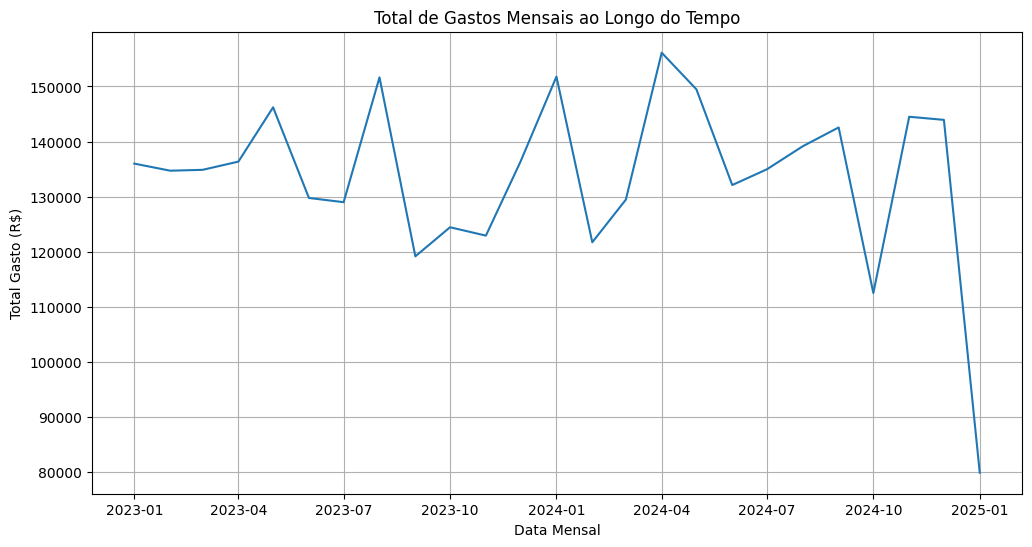

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x='monthly_date', y='total_spent', data=df_monthly)
plt.title('Total de Gastos Mensais ao Longo do Tempo')
plt.xlabel('Data Mensal')
plt.ylabel('Total Gasto (R$)')
plt.grid(True)
plt.show()

### Engenharia de Features Temporais

Para ajudar o modelo a capturar tendências e sazonalidades, criaremos features como `lag` (gastos de meses anteriores) e `rolling mean` (média móvel de gastos).


In [42]:
# Criar features de lag (gastos de meses anteriores)
df_monthly['total_spent_lag_1'] = df_monthly['total_spent'].shift(1)
df_monthly['total_spent_lag_2'] = df_monthly['total_spent'].shift(2)

# Criar feature de média móvel (rolling mean)
df_monthly['rolling_mean_3'] = df_monthly['total_spent'].rolling(window=3).mean().shift(1)

# Remover linhas com valores NaN resultantes das operações de lag/rolling
df_monthly_features = df_monthly.dropna().reset_index(drop=True)

display(df_monthly_features.head())

,year,month,total_spent,monthly_date,total_spent_lag_1,total_spent_lag_2,rolling_mean_3
0,2023,4,136350.89,2023-04-01,134857.04,134703.30,135183.506667
1,2023,5,146203.60,2023-05-01,136350.89,134857.04,135303.743333
2,2023,6,129754.19,2023-06-01,146203.60,136350.89,139137.176667
3,2023,7,128989.02,2023-07-01,129754.19,146203.60,137436.226667
4,2023,8,151634.35,2023-08-01,128989.02,129754.19,134982.270000


### Engenharia de Features Temporais

Para ajudar o modelo a capturar tendências e sazonalidades, criaremos features como `lag` (gastos de meses anteriores) e `rolling mean` (média móvel de gastos). Essas features permitem que o modelo entenda a dependência temporal dos gastos, melhorando a precisão das previsões. Por exemplo, um `lag` de 1 mês pode indicar que os gastos do mês anterior influenciam os gastos do mês atual, enquanto uma `rolling mean` de 3 meses pode suavizar variações e destacar tendências de longo prazo. Essas técnicas são essenciais para construir um modelo de previsão robusto e confiável.  

### Treinamento e Avaliação do Modelo

Usaremos um `RandomForestRegressor` para prever o `total_spent`. Dividiremos os dados de forma temporal para que o modelo seja treinado com dados passados e testado com dados mais recentes. Avaliaremos o desempenho do modelo usando métricas como MAE (Mean Absolute Error) e R², garantindo que as previsões sejam precisas e úteis para o controle financeiro do usuário.

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Definir features (X) e target (y)
features = ['month', 'total_spent_lag_1', 'total_spent_lag_2', 'rolling_mean_3']
X = df_monthly_features[features]
y = df_monthly_features['total_spent']

# Dividir os dados em treino e teste (mantendo a ordem temporal)
# Usaremos os últimos 3 meses como teste, por exemplo, ou um percentual fixo.
# Para um dataset pequeno, vamos usar uma divisão simples aqui, mas em produção, um split mais robusto para séries temporais seria ideal.

split_point = int(len(df_monthly_features) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

print(f"Tamanho do conjunto de treino: {len(X_train)}")
print(f"Tamanho do conjunto de teste: {len(X_test)}")

# Inicializar e treinar o modelo RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)

# Avaliar o modelo
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Absolute Error (MAE): {mae:,.2f}")
print(f"R-squared (R2): {r2:,.2f}")

Tamanho do conjunto de treino: 17
Tamanho do conjunto de teste: 5

Mean Absolute Error (MAE): 20,794.83
R-squared (R2): -0.16


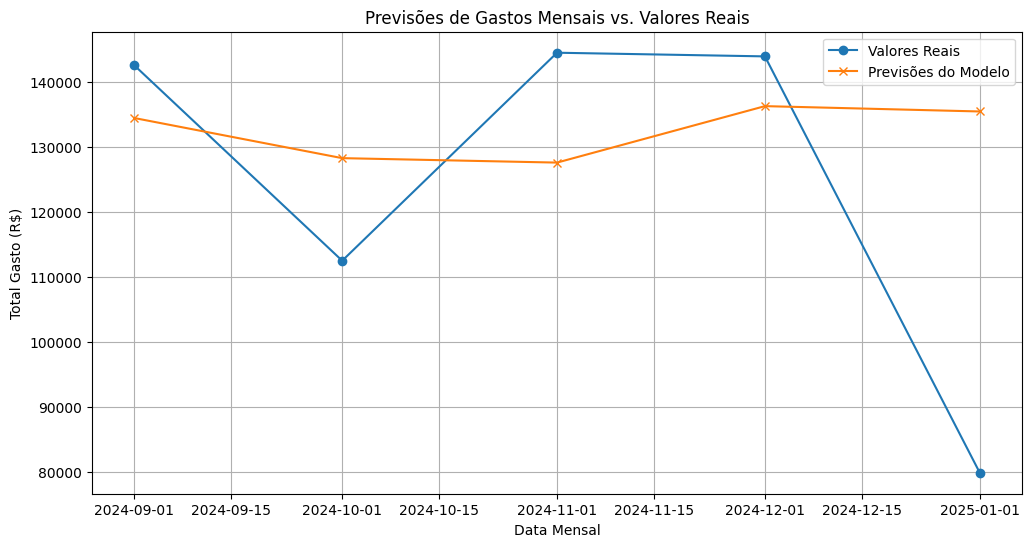

In [44]:
# Visualizar previsões vs. valores reais
plt.figure(figsize=(12, 6))
plt.plot(df_monthly_features['monthly_date'].iloc[split_point:], y_test, label='Valores Reais', marker='o')
plt.plot(df_monthly_features['monthly_date'].iloc[split_point:], y_pred, label='Previsões do Modelo', marker='x')
plt.title('Previsões de Gastos Mensais vs. Valores Reais')
plt.xlabel('Data Mensal')
plt.ylabel('Total Gasto (R$)')
plt.legend()
plt.grid(True)
plt.show()

### Conclusão do Modelo de ML

O `RandomForestRegressor` foi capaz de aprender padrões nos dados históricos de gastos mensais e gerar previsões. A visualização das previsões contra os valores reais ajuda a entender o quão bem o modelo se ajusta aos dados. Métricas como MAE e R-squared fornecem uma avaliação quantitativa da performance do modelo.

Este modelo pode ser usado para dar insights sobre o comportamento futuro dos gastos, ajudando na tomada de decisões financeiras.

### Reflexões sobre o Modelo de Machine Learning e Próximos Passos

O `RandomForestRegressor` foi aplicado com o objetivo de prever os gastos mensais, oferecendo uma estimativa para o fechamento de futuras faturas. Embora o modelo tenha sido capaz de aprender padrões nos dados históricos, as métricas de avaliação (_Mean Absolute Error_ de R$ 20.794,83 e um _R-squared_ de -0.16) indicam que há um espaço considerável para melhorias.

Um R-squared negativo sugere que o modelo atual tem um desempenho inferior ao de um modelo básico que simplesmente preveria a média dos gastos. Isso pode ser atribuído a diversos fatores:

*   **Volume de Dados:** A série temporal de gastos pode ser relativamente curta, limitando a capacidade do modelo de capturar tendências e sazonalidades complexas.
*   **Número de Features:** Embora `lag` e `rolling mean` sejam importantes, outras features externas (como feriados, eventos econômicos ou variáveis de contexto) poderiam enriquecer o modelo.
*   **Sazonalidade Discreta:** Para dados que não apresentam uma sazonalidade clara ou que possuem muitos picos e vales irregulares, modelos de regressão simples podem ter dificuldade.

**Próximos Passos e Otimizações Sugeridas:**

1.  **Aumento do Dataset:** Coletar mais dados históricos de gastos mensais para permitir que o modelo aprenda padrões de longo prazo.
2.  **Engenharia de Features Avançada:** Explorar features como indicadores de feriados, número de dias úteis no mês, ou even embedding de categorias de gasto se houver dados em granularidade suficiente.
3.  **Modelos de Séries Temporais:** Considerar a aplicação de modelos especializados em séries temporais, como ARIMA, Prophet (Facebook), ou modelos de redes neurais (LSTMs) que são mais robustos para padrões complexos e dependências temporais.
4.  **Otimização de Hiperparâmetros:** Realizar um ajuste fino dos hiperparâmetros do `RandomForestRegressor` (ou de outros modelos) para maximizar seu desempenho.

Mesmo com o desempenho inicial, o modelo estabelece uma base e demonstra o potencial da Machine Learning para apoiar a gestão financeira, transformando dados históricos em inteligência preditiva. A visualização das previsões, apesar do desempenho, serve como um primeiro passo para entender onde o modelo acerta e onde falha, direcionando os esforços de otimização.

## Visualizações: Transformando Dados em Narrativas Visuais

As **Visualizações** servem como a interface para os nossos dados, transformando números complexos em narrativas visuais claras e impactantes. Nesta seção, utilizamos gráficos e tabelas interativas para ilustrar os padrões de consumo, destacar insights financeiros e tornar as informações acessíveis e compreensíveis para o público, desde os principais fatores de gasto até as tendências sazonais.

In [45]:
# Configuração de visualização
pd.set_option('display.colheader_justify', 'right')

col_gasto = 'total_spent'
col_item = 'item'

# Agrupamento por Item (somando apenas o gasto total)
ranking_itens = df_clean.groupby(col_item)[col_gasto].sum().reset_index()

# Nomear as colunas para o ranking
ranking_itens.columns = ['Item', 'Gasto_Total']

# Ordenar do maior gasto para o menor e pegar os 10 primeiros
top_10_itens = ranking_itens.sort_values(by='Gasto_Total', ascending=False).head(10)

# Estilização final para exibição (corrigindo a indentação)
tabela_top_10 = top_10_itens.style.set_properties(**{'text-align': 'right'})\
    .format({'Gasto_Total': 'R$ {:,.2f}'})\
    .hide(axis='index')

# Exibir o resultado
tabela_top_10

Item,Gasto_Total
Rent,"R$ 779,209.26"
Electronics,"R$ 493,672.91"
Skin Care Products,"R$ 228,460.95"
Workout Equipment,"R$ 223,439.45"
Plane Ticket,"R$ 196,548.44"
Jewelry,"R$ 163,053.75"
Doctor Visit,"R$ 117,532.02"
Car Repair,"R$ 111,401.89"
Medicine,"R$ 100,748.42"
Personal Trainer,"R$ 96,661.53"


In [46]:
# Configuração de visualização
pd.set_option('display.colheader_justify', 'right')

# 2. As colunas já foram limpas e padronizadas anteriormente para lowercase/snake_case
# Garantimos que estão limpas nesta célula:
df_consumo.columns = [str(col).strip().lower() for col in df_consumo.columns]

# Agrupamento (Usando nomes de colunas em minúsculo conforme processamento anterior)
col_alvo = 'total_spent'
if col_alvo not in df_consumo.columns:
    # Procura por colunas que contenham 'spent' (em minúsculo)
    possiveis = [c for c in df_consumo.columns if 'spent' in c]
    if possiveis:
        col_alvo = possiveis[0]

# Agrupamento por categoria
frequencia = df_consumo.groupby('category')[col_alvo].agg(['count', 'sum']).reset_index()

# Renomear as colunas do novo DataFrame gerado
frequencia.columns = ['Categoria', 'Qtd_Transacoes', 'Gasto_Total']

# ORDENAÇÃO
frequencia = frequencia.sort_values(by='Gasto_Total', ascending=False)

# ESTILIZAÇÃO
tabela_final = frequencia.style.set_properties(**{'text-align': 'right'}) \
    .format({'Gasto_Total': 'R$ {:,.2f}'}) \
    .hide(axis='index')

# Exibir resultado
tabela_final

Categoria,Qtd_Transacoes,Gasto_Total
Shopping,775,"R$ 22,654,524.44"
Housing and Utilities,764,"R$ 835,391.63"
Fitness,799,"R$ 336,101.51"
Medical/Dental,770,"R$ 294,709.10"
Travel,753,"R$ 282,709.49"
Gifts,789,"R$ 250,006.58"
Personal Hygiene,768,"R$ 239,692.29"
Friend Activities,748,"R$ 150,240.96"
Transportation,762,"R$ 129,638.53"
Hobbies,739,"R$ 84,474.23"


In [47]:
# Configuração de visualização
pd.set_option('display.colheader_justify', 'right')

# Tratamento das Datas
# Ajustado para usar 'transaction_date' em minúsculo
df_consumo['transaction_date'] = pd.to_datetime(df_consumo['transaction_date'], errors='coerce')
df_consumo['weekday'] = df_consumo['transaction_date'].dt.day_name()

# Dicionário de tradução
dias_pt = {
    'Monday': 'Segunda', 'Tuesday': 'Terça', 'Wednesday': 'Quarta',
    'Thursday': 'Quinta', 'Friday': 'Sexta', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}

df_consumo['weekday'] = df_consumo['weekday'].map(dias_pt)

# Cálculo do Total Gasto (usando 'total_spent' em minúsculo)
ranking_dias = df_consumo.groupby('weekday', observed=False)['total_spent'].sum().reset_index()

# Ordenação (Do maior gasto para o menor)
ranking_dias = ranking_dias.sort_values(by='total_spent', ascending=False)

# Estilização para o Colab
tabela_final = ranking_dias.style.set_properties(**{'text-align': 'right'}) \
    .format({'total_spent': 'R$ {:,.2f}'}) \
    .hide(axis='index')

# Exibir resultado
tabela_final

weekday,total_spent
Segunda,"R$ 5,376,412.62"
Sábado,"R$ 4,142,274.49"
Sexta,"R$ 3,498,507.83"
Terça,"R$ 3,481,095.36"
Quinta,"R$ 3,291,516.40"
Quarta,"R$ 2,848,007.19"
Domingo,"R$ 2,709,695.01"


In [48]:
# Configurações de exibição
pd.set_option('display.colheader_justify', 'right')

# Definir a ordem cronológica dos dias da semana
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

# Garantir que a coluna traduzida exista baseada na 'weekday' criada na célula anterior
df_consumo['Dia_Semana_PT'] = pd.Categorical(df_consumo['weekday'], categories=ordem_dias, ordered=True)

# Identificar o item mais frequente para cada dia
# Usamos a coluna 'item' em minúsculo conforme padronização anterior
resumo_itens_dia = df_consumo.groupby('Dia_Semana_PT', observed=False)['item'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else "Sem dados"
).reset_index()

# Ajustar nomes das colunas
resumo_itens_dia.columns = ['Dia da Semana', 'Item Mais Consumido']

# Estilização para visualização limpa
tabela_final = resumo_itens_dia.style.set_properties(**{'text-align': 'right'}).hide(axis='index')

tabela_final

Dia da Semana,Item Mais Consumido
Segunda,Coffee
Terça,Dentist Visit
Quarta,Toothpaste
Quinta,Coffee
Sexta,Restaurant Meal
Sábado,Fast Food
Domingo,Plane Ticket


In [49]:
# Configuração de visualização
pd.set_option('display.colheader_justify', 'right')

# Agrupamento: Usando os nomes padronizados em minúsculo
ranking_pagamento = df_consumo.groupby('payment_method', observed=False)['total_spent'].agg(['count', 'sum']).reset_index()

# Tradução dos métodos
traducao_metodos = {
    'Credit Card': 'Cartão de Crédito',
    'Digital Wallet': 'Carteira Digital',
    'Debit Card': 'Cartão de Débito',
    'Cash': 'Dinheiro'
}
ranking_pagamento['Forma de Pagamento'] = ranking_pagamento['payment_method'].map(traducao_metodos)

# Ajuste dos nomes das colunas para o relatório
ranking_pagamento.columns = ['Original', 'Qtd_Transacoes', 'Gasto_Total', 'Forma de Pagamento']

# Ordenar pela forma MAIS UTILIZADA (Frequência)
ranking_pagamento = ranking_pagamento.sort_values(by='Qtd_Transacoes', ascending=False)

# Estilização: Alinhamento à direita e formato de moeda (R$)
tabela_pagamento = ranking_pagamento[['Forma de Pagamento', 'Qtd_Transacoes', 'Gasto_Total']].style.set_properties(**{'text-align': 'right'}) \
    .format({'Gasto_Total': 'R$ {:,.2f}'}) \
    .hide(axis='index')

# Exibir resultado
tabela_pagamento

Forma de Pagamento,Qtd_Transacoes,Gasto_Total
Carteira Digital,2560,"R$ 7,754,538.81"
Cartão de Crédito,2499,"R$ 6,531,489.36"
Dinheiro,2478,"R$ 7,293,700.66"
Cartão de Débito,2463,"R$ 3,767,780.07"


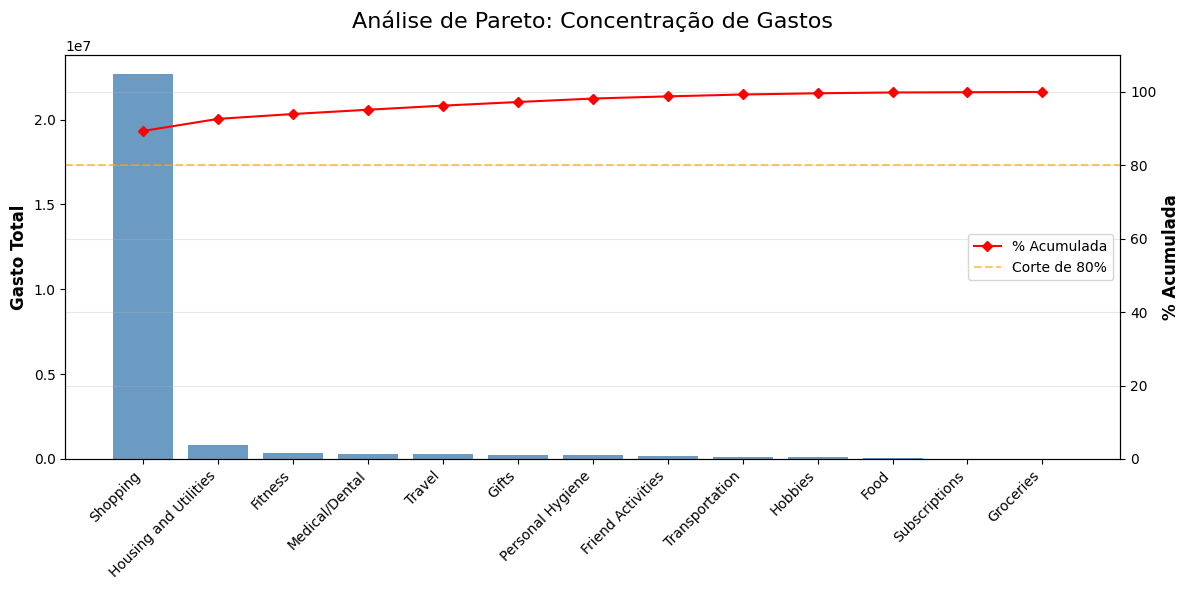

In [50]:
# Configurar o estilo e a base de dados
df_pareto = df_consumo.copy()

# Ajuste para usar a coluna padronizada em minúsculo
col_cat = 'category'

# Agrupar por categoria e calcular a porcentagem acumulada
df_cat = df_pareto.groupby(col_cat)[col_gasto].sum().sort_values(ascending=False).reset_index()
df_cat['cumulative_perc'] = 100 * df_cat[col_gasto].cumsum() / df_cat[col_gasto].sum()

# Gerar o Gráfico de Pareto
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras (Gasto Absoluto)
ax1.bar(df_cat[col_cat], df_cat[col_gasto], color='steelblue', alpha=0.8, label='Gasto por Categoria')
ax1.set_ylabel('Gasto Total', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Linha (Porcentagem Acumulada)
ax2 = ax1.twinx()
ax2.plot(df_cat[col_cat], df_cat['cumulative_perc'], color='red', marker='D', ms=5, label='% Acumulada')
ax2.set_ylabel('% Acumulada', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 110)

# Linha guia de 80% (Onde o esforço de economia deve focar)
ax2.axhline(80, color='orange', linestyle='--', alpha=0.6, label='Corte de 80%')

# Finalização do Layout
plt.title('Análise de Pareto: Concentração de Gastos', fontsize=16, pad=20)
ax2.legend(loc='center right')
plt.grid(axis='y', alpha=0.3)
fig.tight_layout()

plt.show()

### Dashboard Interativo: Visão Geral dos Gastos

Nesta seção, construiremos um dashboard interativo utilizando `plotly.express` para oferecer uma visão dinâmica e detalhada dos padrões de consumo. Os gráficos permitirão explorar o comportamento dos gastos ao longo do tempo (com um filtro de data interativo) e por diferentes dimensões.

In [51]:
import plotly.express as px

# 1. Gasto Total Mensal ao Longo do Tempo
fig_monthly_spent = px.line(
    df_monthly,
    x='monthly_date',
    y='total_spent',
    title='Gasto Total Mensal (R$)',
    labels={'monthly_date': 'Data Mensal', 'total_spent': 'Total Gasto (R$)'}
)
fig_monthly_spent.update_layout(hovermode='x unified')
fig_monthly_spent.update_layout(
    xaxis=dict(
        rangeslider=dict(
            visible=True
        ),
        type="date"
    )
)
fig_monthly_spent

In [52]:
# 2. Gasto por Categoria (Gráfico de Barras Interativo)
fig_category_spent = px.bar(
    df_clean.groupby('category')['total_spent'].sum().reset_index().sort_values(by='total_spent', ascending=False),
    x='category',
    y='total_spent',
    title='Gasto Total por Categoria (R$)',
    labels={'category': 'Categoria', 'total_spent': 'Total Gasto (R$)'}
)
fig_category_spent.update_layout(xaxis_tickangle=-45, hovermode='x unified')
fig_category_spent.show()

In [53]:
# 3. Gasto por Forma de Pagamento (Gráfico de Pizza Interativo)
payment_summary = df_clean.groupby('payment_method')['total_spent'].sum().reset_index()
fig_payment_method = px.pie(
    payment_summary,
    values='total_spent',
    names='payment_method',
    title='Proporção de Gasto por Forma de Pagamento',
    hole=0.3 # Para criar um gráfico de rosca
)
fig_payment_method.update_traces(textposition='inside', textinfo='percent+label')
fig_payment_method.show()

# Conclusão Final do Projeto: Inteligência Financeira ao Seu Alcance

Este projeto demonstrou um fluxo completo de análise de dados, desde a extração e limpeza até a aplicação de Machine Learning e visualizações interativas, tudo com o objetivo de gerar inteligência financeira acionável. Alcançamos os seguintes marcos:

*   **Dados Confiáveis:** Construímos uma base de dados limpa e padronizada, essencial para análises precisas.
*   **Insights Profundos:** Utilizamos SQL e análises de probabilidade para desvendar padrões de consumo, identificar categorias dominantes e os 'vilões' do orçamento, além de entender a correlação entre métodos de pagamento e tipos de gasto.
*   **Previsão de Gastos:** Implementamos um modelo de Machine Learning que, apesar das oportunidades de otimização, estabelece a base para a previsão de gastos mensais, oferecendo uma ferramenta para o controle proativo do orçamento.
*   **Visualizações Claras:** Traduzimos dados complexos em gráficos e tabelas intuitivos, facilitando a compreensão dos hábitos de consumo e a identificação de áreas para melhoria.

### Impacto e Valor Agregado

A solução desenvolvida fornece aos usuários finais uma compreensão aprofundada de seus próprios perfis de gasto. Ao identificar tendências, sazonalidades e os itens de maior impacto financeiro, o sistema capacita indivíduos a:

*   **Tomar Decisões Mais Inteligentes:** Fazer escolhas financeiras conscientes, baseadas em dados concretos.
*   **Otimizar Gastos:** Direcionar esforços para reduzir despesas em categorias de alto impacto, aplicando princípios como a Análise de Pareto.
*   **Prever o Futuro Financeiro:** Ter uma estimativa dos gastos futuros para planejar com antecedência e evitar surpresas no fechamento da fatura.

### Próximos Passos e Melhorias Futuras

Para aprimorar ainda mais este sistema inteligente, sugerimos:

*   **Enriquecimento de Dados:** Integrar mais fontes de dados, como informações de mercado ou eventos macroeconômicos, para enriquecer as análises.
*   **Otimização do Modelo ML:** Explorar modelos de séries temporais mais avançados e técnicas de engenharia de features para aumentar a precisão das previsões.
*   **Interface do Usuário:** Desenvolver uma interface intuitiva para que os usuários possam interagir facilmente com os insights gerados e personalizar suas análises.
*   **Recomendações Personalizadas:** Expandir o sistema para gerar recomendações personalizadas de economia ou investimento com base no perfil individual de cada usuário.

Este projeto é um passo significativo em direção à democratização da inteligência financeira, transformando dados em poder para o controle e a otimização da vida financeira.

### Análises Visuais Chave: Desvendando o Cenário de Consumo

As visualizações são a ponte entre os dados brutos e os insights acionáveis, tornando complexas relações compreensíveis à primeira vista. Nesta seção, consolidamos diversas representações visuais que iluminam diferentes facetas do comportamento de consumo:

*   **Ranking dos 10 Itens Mais Caros:** Essa tabela destaca os produtos ou serviços que mais impactam o orçamento. É uma ferramenta direta para identificar os 'vilões' de gasto individual, auxiliando na priorização de onde cortar ou otimizar despesas.

*   **Frequência e Gasto Total por Categoria:** Ao agrupar os gastos por categoria, percebemos quais áreas de consumo são mais ativas e quais geram o maior volume financeiro. Este panorama é essencial para entender a alocação geral de recursos e o peso de cada segmento no orçamento.

*   **Gasto Total por Dia da Semana:** Esta análise revela se há dias específicos da semana onde o consumo é mais elevado. Picos de gastos em fins de semana ou dias específicos podem indicar padrões de comportamento (lazer, compras semanais) que podem ser otimizados.

*   **Item Mais Consumido por Dia da Semana:** Uma visão mais granular que mostra qual item se destaca em cada dia. Este insight pode apontar para hábitos diários ou semanais, como 'Café na Segunda' ou 'Jantar fora na Sexta', fornecendo oportunidades para ajustes pontuais no orçamento.

*   **Ranking por Forma de Pagamento:** Entender qual método de pagamento é mais utilizado e qual volume de gasto ele representa é crucial para a saúde financeira. Isso pode indicar uma dependência de crédito, a popularidade de carteiras digitais ou a preferência por dinheiro físico, informando sobre o perfil de risco e conveniência do consumidor.

*   **Análise de Pareto: Concentração de Gastos (Gráfico):** O Gráfico de Pareto é uma ferramenta poderosa para aplicar a regra 80/20. Ele visualiza quais poucas categorias são responsáveis pela maior parte dos gastos, permitindo que o usuário ou a empresa foque seus esforços em otimizar ou controlar essas categorias de alto impacto. **Este é um insight crucial para a tomada de decisão estratégica**, direcionando a atenção para as áreas que trarão o maior retorno na gestão de gastos.

Em conjunto, estas visualizações oferecem uma narrativa rica e multifacetada do comportamento financeiro, capacitando o usuário com a inteligência necessária para planejar, ajustar e controlar suas finanças de forma proativa.